# GCM and RCM (new)

In [1]:
import os
import glob
import json
import numpy as np
import torch
import torch.nn.functional as F
import xarray as xr

try:
    import xesmf as xe
except ImportError:
    xe = None



# =========================================================
# settings
# =========================================================
rcm_var = "prec"      # HR RCM target variable
gcm_var = "pr"        # GCM input variable

gcm_name = "CanESM2"
rcm_name = "RCA4"
grid = "NAM-44i"

# RCM product type:
# - "mbcn-gridMET": bias-corrected data already on a regular lat/lon grid
# - "raw": native CORDEX rotated-pole grid; regridded below before preprocessing
rcm_product = "raw"
raw_hr_res = 0.5

factor = 4

# Choose the preprocessing branch to save:
# - "GCM_RCM": low_res.pth is LR GCM, high_res.pth is HR RCM
# - "RCM_RCM": low_res.pth is coarsened LR RCM, high_res.pth is HR RCM
preprocess_mode = "RCM_RCM"

if preprocess_mode not in ["GCM_RCM", "RCM_RCM"]:
    raise ValueError(f"Unknown preprocess_mode={preprocess_mode}")

requires_gcm = preprocess_mode == "GCM_RCM"

lat_min, lat_max = 24, 50
lon_min, lon_max = -125, -66

gcm_dir = "/projects/sds-lab/Shuochen/downscaling/GCM"

# PRISM elevation NetCDF. NaNs define ocean/non-land for the land-sea mask.
elev_nc_path = "/projects/sds-lab/Shuochen/downscaling/old/elevation.nc"

rcm_path = (
    f"/projects/sds-lab/Shuochen/downscaling/CORDEX/"
    f"{rcm_var}.*.{gcm_name}.{rcm_name}.day.{grid}.{rcm_product}.nc"
)

gcm_path = (
    f"{gcm_dir}/"
    f"{gcm_var}_day_{gcm_name}_*_r1i1p1_*.nc"
)

preprocessed_dir = "/projects/sds-lab/Shuochen/downscaling/preprocessed"
os.makedirs(preprocessed_dir, exist_ok=True)

out_tag = f"{rcm_product}.{preprocess_mode}"

out_dir = (
    f"{preprocessed_dir}/"
    f"{rcm_var}.{gcm_name}.{rcm_name}.day.{grid}.{out_tag}"
)

os.makedirs(out_dir, exist_ok=True)


# =========================================================
# output files
# =========================================================
out_high = f"{out_dir}/high_res.pth"                 # HR RCM
out_low = f"{out_dir}/low_res.pth"                   # selected LR input

# GCM interpolated directly to HR RCM grid, saved only for GCM_RCM mode.
out_gcm_upscaled = f"{out_dir}/high_res_gcm.pth"

out_mask_high = f"{out_dir}/high_res_mask.pth"
out_mask_low = f"{out_dir}/low_res_mask.pth"

# elevation outputs
out_elev_high = f"{out_dir}/high_res_elevation.pth"
out_elev_low = f"{out_dir}/low_res_elevation.pth"


# =========================================================
# helper functions
# =========================================================
def find_lat_lon_names(da, require_dims=True):
    lat_name, lon_name = None, None

    for name in da.coords:
        low = name.lower()
        if low in ["lat", "latitude"]:
            lat_name = name
        elif low in ["lon", "longitude"]:
            lon_name = name

    if lat_name is None or lon_name is None:
        raise ValueError("Could not find lat/lon coordinates.")

    if require_dims and (lat_name not in da.dims or lon_name not in da.dims):
        raise ValueError("lat/lon must be dimensions.")

    return lat_name, lon_name


def convert_lon_to_minus180_180(da, lon_name):
    lon = da[lon_name]

    if lon.max() > 180:
        da = da.assign_coords(
            {lon_name: (((lon + 180) % 360) - 180)}
        )
        if lon_name in da.dims:
            da = da.sortby(lon_name)

    return da


def find_spatial_dim_names(da, lat_name, lon_name):
    if lat_name in da.dims and lon_name in da.dims:
        return lat_name, lon_name

    lat_dims = da[lat_name].dims
    lon_dims = da[lon_name].dims

    if len(lat_dims) == 2 and lat_dims == lon_dims:
        return lat_dims

    raise ValueError(
        "Could not infer spatial dimensions from lat/lon coordinates. "
        f"lat dims={lat_dims}, lon dims={lon_dims}"
    )


def regular_axis(start, stop, step):
    n = int(round((stop - start) / step)) + 1
    return start + step * np.arange(n, dtype=np.float64)


def regrid_raw_rotated_rcm_to_regular_latlon(
    rcm,
    lat_min,
    lat_max,
    lon_min,
    lon_max,
    hr_res,
):
    """
    Regrid native CORDEX raw data from rotated-pole coordinates to a regular
    lat/lon grid before the rest of preprocessing runs.
    """
    if xe is None:
        raise ImportError(
            "rcm_product='raw' requires xesmf. Install/load xesmf in this environment."
        )

    src_lat_name, src_lon_name = find_lat_lon_names(rcm, require_dims=False)
    rcm = convert_lon_to_minus180_180(rcm, src_lon_name)

    y_dim, x_dim = find_spatial_dim_names(rcm, src_lat_name, src_lon_name)
    other_dims = [d for d in rcm.dims if d not in [y_dim, x_dim]]
    rcm = rcm.transpose(*other_dims, y_dim, x_dim)

    src_lat = rcm[src_lat_name]
    src_lon = rcm[src_lon_name]
    region_mask = (
        (src_lat >= lat_min) &
        (src_lat <= lat_max) &
        (src_lon >= lon_min) &
        (src_lon <= lon_max)
    ).compute()

    rcm_region = rcm.where(region_mask, drop=True)

    target_grid = xr.Dataset(
        {
            "lat": (["lat"], regular_axis(lat_min, lat_max, hr_res), {"units": "degrees_north"}),
            "lon": (["lon"], regular_axis(lon_min, lon_max, hr_res), {"units": "degrees_east"}),
        }
    )

    regridder = xe.Regridder(
        rcm_region,
        target_grid,
        method="bilinear",
        periodic=False,
        unmapped_to_nan=True,
    )

    rcm_regular = regridder(rcm_region)
    rcm_regular = rcm_regular.sortby("lat").sortby("lon")

    print("Regridded raw RCM from rotated grid to regular lat/lon grid.")
    print("Raw spatial dims:", y_dim, x_dim)
    print("Regular HR grid shape:", rcm_regular.sizes["lat"], rcm_regular.sizes["lon"])

    return rcm_regular, "lat", "lon"


def standardize_time_to_dates(da):
    """
    Convert time coordinate to YYYY-MM-DD strings.
    This helps align RCM and GCM even if calendars differ slightly.
    """
    if "time" not in da.dims:
        raise ValueError("Expected time dimension in data.")

    dates = da["time"].dt.strftime("%Y-%m-%d")

    da = da.assign_coords(date=("time", dates.data))
    da = da.swap_dims({"time": "date"})
    da = da.drop_vars("time")
    da = da.rename({"date": "time"})

    return da


def is_historical_gcm_file(path):
    return "_historical_" in os.path.basename(path).lower()


def is_rcp_gcm_file(path):
    return "_rcp" in os.path.basename(path).lower()


def get_gcm_file_time_bounds(path):
    with xr.open_dataset(path, decode_times=True) as ds:
        if "time" not in ds.coords and "time" not in ds.dims:
            raise ValueError(f"GCM file has no time coordinate: {path}")

        dates = np.asarray(ds["time"].dt.strftime("%Y-%m-%d").values).astype(str)

    if dates.size == 0:
        raise ValueError(f"GCM file has no time values: {path}")

    dates = [str(date) for date in dates]
    return min(dates), max(dates)


def resolve_gcm_historical_rcp_overlap(files):
    metadata = []
    rcp_start_dates = []

    for path in files:
        start_date, end_date = get_gcm_file_time_bounds(path)
        is_rcp = is_rcp_gcm_file(path)

        metadata.append(
            {
                "path": path,
                "start_date": start_date,
                "end_date": end_date,
                "is_historical": is_historical_gcm_file(path),
                "is_rcp": is_rcp,
            }
        )

        if is_rcp:
            rcp_start_dates.append(start_date)

    if len(rcp_start_dates) == 0:
        return files, None

    rcp_start_date = min(rcp_start_dates)
    has_overlap = any(
        item["is_historical"] and item["end_date"] >= rcp_start_date
        for item in metadata
    )

    if not has_overlap:
        return files, None

    print(
        "Detected overlapping historical/RCP GCM files. "
        f"Using RCP data from {rcp_start_date} onward."
    )

    filtered_files = []
    for item in metadata:
        if item["is_historical"] and item["start_date"] >= rcp_start_date:
            print(
                "Skipping historical GCM file fully inside the RCP period:",
                os.path.basename(item["path"]),
            )
            continue

        filtered_files.append(item["path"])

    return filtered_files, rcp_start_date


def make_gcm_overlap_preprocessor(rcp_start_date):
    def preprocess(ds):
        source = ds.encoding.get("source", "")

        if not is_historical_gcm_file(source) or "time" not in ds.dims:
            return ds

        time_dates = np.asarray(ds["time"].dt.strftime("%Y-%m-%d").values).astype(str)
        keep = np.asarray([str(date) < rcp_start_date for date in time_dates], dtype=bool)
        before = ds.sizes["time"]
        after = int(keep.sum())

        if after == 0:
            raise ValueError(
                "Historical GCM file has no samples before RCP start date "
                f"{rcp_start_date}: {source}"
            )

        if after < before:
            print(
                "Trimming historical GCM overlap:",
                os.path.basename(source),
                f"kept {after}/{before} samples before {rcp_start_date}",
            )

        return ds.isel(time=keep)

    return preprocess


def maybe_convert_gcm_units(gcm, rcm):
    """
    Convert GCM tas units to match RCM tmean units when units metadata is available.
    CanESM2 tas is often in K. Some downscaling targets may be in degC.
    """
    gcm_units = str(gcm.attrs.get("units", "")).lower()
    rcm_units = str(rcm.attrs.get("units", "")).lower()

    gcm_is_k = ("k" == gcm_units) or ("kelvin" in gcm_units)
    rcm_is_k = ("k" == rcm_units) or ("kelvin" in rcm_units)

    gcm_is_c = ("c" == gcm_units) or ("celsius" in gcm_units) or ("degc" in gcm_units)
    rcm_is_c = ("c" == rcm_units) or ("celsius" in rcm_units) or ("degc" in rcm_units)

    if gcm_is_k and rcm_is_c:
        print("Converting GCM tas from K to degC.")
        gcm = gcm - 273.15
        gcm.attrs["units"] = rcm.attrs.get("units", "degC")

    elif gcm_is_c and rcm_is_k:
        print("Converting GCM tas from degC to K.")
        gcm = gcm + 273.15
        gcm.attrs["units"] = rcm.attrs.get("units", "K")

    else:
        print("No automatic unit conversion applied.")
        print("GCM units:", gcm_units)
        print("RCM units:", rcm_units)

    return gcm


def create_elevation_from_prism(
    elevation_path,
    lat_1d,
    lon_1d,
    land_mask_2d=None,
    method="linear",
    fill_nan=True,
):
    """
    Interpolate PRISM elevation onto the target lat/lon grid.

    The PRISM elevation file has NaNs outside land coverage, so finite values
    are also used to derive the land-sea mask for raw RCM data.
    """
    elev_ds = xr.open_dataset(elevation_path)

    if "elevation" not in elev_ds:
        raise ValueError(f"No 'elevation' variable found in {elevation_path}")

    elev = elev_ds["elevation"]

    if "lat" not in elev.coords or "lon" not in elev.coords:
        raise ValueError("PRISM elevation must have lat/lon coordinates.")

    elev = convert_lon_to_minus180_180(elev, "lon")
    elev = elev.sortby("lat").sortby("lon")

    elev_on_grid = elev.interp(
        lat=xr.DataArray(lat_1d, dims="lat"),
        lon=xr.DataArray(lon_1d, dims="lon"),
        method=method,
    )

    elev_arr = elev_on_grid.values.astype(np.float32)

    if land_mask_2d is not None:
        elev_arr = elev_arr * land_mask_2d.astype(np.float32)

    if fill_nan:
        elev_arr = np.nan_to_num(elev_arr, nan=0.0)

    elev_ds.close()
    return elev_arr


# =========================================================
# check input files
# =========================================================
rcm_files = sorted(glob.glob(rcm_path))
gcm_files = sorted(glob.glob(gcm_path)) if requires_gcm else []

if len(rcm_files) == 0:
    raise FileNotFoundError(f"No RCM files found with pattern:\n{rcm_path}")

if requires_gcm and len(gcm_files) == 0:
    raise FileNotFoundError(f"No GCM files found with pattern:\n{gcm_path}")

if requires_gcm:
    gcm_files, gcm_rcp_start_date = resolve_gcm_historical_rcp_overlap(gcm_files)
else:
    gcm_rcp_start_date = None

print("Preprocess mode:", preprocess_mode)
print("Number of RCM files:", len(rcm_files))
if requires_gcm:
    print("Number of GCM files:", len(gcm_files))


# =========================================================
# open HR RCM target
# =========================================================
rcm = xr.open_mfdataset(rcm_files)[rcm_var]

if rcm_product == "raw":
    rcm, rcm_lat_name, rcm_lon_name = regrid_raw_rotated_rcm_to_regular_latlon(
        rcm=rcm,
        lat_min=lat_min,
        lat_max=lat_max,
        lon_min=lon_min,
        lon_max=lon_max,
        hr_res=raw_hr_res,
    )
else:
    rcm_lat_name, rcm_lon_name = find_lat_lon_names(rcm)

    rcm = convert_lon_to_minus180_180(rcm, rcm_lon_name)

    rcm = rcm.sel(
        {
            rcm_lat_name: slice(lat_min, lat_max),
            rcm_lon_name: slice(lon_min, lon_max),
        }
    )

    rcm = rcm.sortby(rcm_lat_name).sortby(rcm_lon_name)

if rcm_var == "tas":
    print("Converting RCM tas from K to degC.")
    rcm = rcm - 273.15
    rcm.attrs["units"] = "degC"


# =========================================================
# open GCM input
# =========================================================
if requires_gcm:
    gcm_open_kwargs = {}
    if gcm_rcp_start_date is not None:
        gcm_open_kwargs["preprocess"] = make_gcm_overlap_preprocessor(gcm_rcp_start_date)

    gcm = xr.open_mfdataset(gcm_files, **gcm_open_kwargs)[gcm_var]

    gcm_lat_name, gcm_lon_name = find_lat_lon_names(gcm)

    gcm = convert_lon_to_minus180_180(gcm, gcm_lon_name)
    gcm = gcm.sortby(gcm_lat_name).sortby(gcm_lon_name)

    # select slightly larger GCM region before interpolation
    buffer_deg = 5

    gcm = gcm.sel(
        {
            gcm_lat_name: slice(lat_min - buffer_deg, lat_max + buffer_deg),
            gcm_lon_name: slice(lon_min - buffer_deg, lon_max + buffer_deg),
        }
    )

    gcm = maybe_convert_gcm_units(gcm, rcm)
else:
    gcm = None
    gcm_lat_name = None
    gcm_lon_name = None


# =========================================================
# trim HR RCM so H and W are divisible by factor
# =========================================================
rcm_lat = np.asarray(rcm[rcm_lat_name].values)
rcm_lon = np.asarray(rcm[rcm_lon_name].values)

other_dims = [d for d in rcm.dims if d not in [rcm_lat_name, rcm_lon_name]]
rcm = rcm.transpose(*other_dims, rcm_lat_name, rcm_lon_name)

H, W = rcm.shape[-2], rcm.shape[-1]

Hf = (H // factor) * factor
Wf = (W // factor) * factor

if Hf == 0 or Wf == 0:
    raise ValueError("Grid too small after enforcing factor.")

trim_lat = H - Hf
trim_lon = W - Wf

top = trim_lat // 2
bottom = top + Hf

left = trim_lon // 2
right = left + Wf

rcm = rcm.isel(
    {
        rcm_lat_name: slice(top, bottom),
        rcm_lon_name: slice(left, right),
    }
)

lat_trim = np.asarray(rcm[rcm_lat_name].values)
lon_trim = np.asarray(rcm[rcm_lon_name].values)

print(f"Original HR RCM shape: ({H}, {W})")
print(f"Trimmed HR RCM shape: ({Hf}, {Wf})")
print(f"LR shape: ({Hf // factor}, {Wf // factor})")
print(f"Factor: {factor}")


# =========================================================
# define LR grid from HR RCM grid
# =========================================================
# This grid is used for both:
# 1. GCM low_res
# 2. coarsened RCM coarse_4x
lr_lat = lat_trim[factor // 2 :: factor]
lr_lon = lon_trim[factor // 2 :: factor]

lr_lat = lr_lat[: Hf // factor]
lr_lon = lr_lon[: Wf // factor]

print("LR lat size:", len(lr_lat))
print("LR lon size:", len(lr_lon))


# =========================================================
# regrid GCM tas to LR grid
# =========================================================
if requires_gcm:
    gcm_lr = gcm.interp(
        {
            gcm_lat_name: xr.DataArray(lr_lat, dims="lat_lr"),
            gcm_lon_name: xr.DataArray(lr_lon, dims="lon_lr"),
        },
        method="linear",
    )

    # Keep LR spatial dimensions different from HR RCM dimensions.
    # Do NOT rename lat_lr/lon_lr to lat/lon before time alignment.
    gcm_lr = gcm_lr.transpose("time", "lat_lr", "lon_lr")
else:
    gcm_lr = None


# =========================================================
# regrid GCM tas directly to HR RCM grid
# =========================================================
# This is the upscaled GCM field on the same grid as high_res.pth.
# It can be used as an HR auxiliary input channel.
if requires_gcm:
    gcm_upscaled = gcm.interp(
        {
            gcm_lat_name: xr.DataArray(lat_trim, dims="lat_hr"),
            gcm_lon_name: xr.DataArray(lon_trim, dims="lon_hr"),
        },
        method="linear",
    )

    gcm_upscaled = gcm_upscaled.transpose("time", "lat_hr", "lon_hr")
else:
    gcm_upscaled = None


# =========================================================
# align time only between GCM input and RCM target
# =========================================================
rcm_time_aligned = standardize_time_to_dates(rcm)

# Drop possible duplicate dates
rcm_time_aligned = rcm_time_aligned.isel(
    time=~rcm_time_aligned.get_index("time").duplicated()
)

if requires_gcm:
    gcm_time_aligned = standardize_time_to_dates(gcm_lr)
    gcm_upscaled_time_aligned = standardize_time_to_dates(gcm_upscaled)

    gcm_time_aligned = gcm_time_aligned.isel(
        time=~gcm_time_aligned.get_index("time").duplicated()
    )

    gcm_upscaled_time_aligned = gcm_upscaled_time_aligned.isel(
        time=~gcm_upscaled_time_aligned.get_index("time").duplicated()
    )

    # Align by common dates only
    common_times = np.intersect1d(
        rcm_time_aligned["time"].values,
        gcm_time_aligned["time"].values,
    )

    common_times = np.intersect1d(
        common_times,
        gcm_upscaled_time_aligned["time"].values,
    )

    if len(common_times) == 0:
        raise ValueError("No overlapping dates found between RCM and GCM.")

    rcm_time_aligned = rcm_time_aligned.sel(time=common_times)
    gcm_time_aligned = gcm_time_aligned.sel(time=common_times)
    gcm_upscaled_time_aligned = gcm_upscaled_time_aligned.sel(time=common_times)
else:
    gcm_time_aligned = None
    gcm_upscaled_time_aligned = None

print("Aligned samples:", rcm_time_aligned.sizes["time"])
print("First aligned date:", rcm_time_aligned["time"].values[0])
print("Last aligned date:", rcm_time_aligned["time"].values[-1])

print("RCM aligned shape:", rcm_time_aligned.shape)
if requires_gcm:
    print("GCM aligned shape:", gcm_time_aligned.shape)
    print("GCM upscaled aligned shape:", gcm_upscaled_time_aligned.shape)


# =========================================================
# load arrays
# =========================================================
# Cast to float32 before loading to reduce memory.
print("Casting aligned arrays to float32...")
rcm_time_aligned = rcm_time_aligned.astype("float32")
if requires_gcm:
    gcm_time_aligned = gcm_time_aligned.astype("float32")
    gcm_upscaled_time_aligned = gcm_upscaled_time_aligned.astype("float32")

print("Loading HR RCM array...")
hr = rcm_time_aligned.load().values          # [time, H, W]

if requires_gcm:
    print("Loading GCM low_res array...")
    gcm_low = gcm_time_aligned.load().values         # [time, h, w]

    print("Loading GCM upscaled array...")
    gcm_up = gcm_upscaled_time_aligned.load().values    # [time, H, W]
else:
    gcm_low = None
    gcm_up = None


# =========================================================
# masks before filling NaNs
# =========================================================
# Full time dimension HR mask.
# The LR land-sea mask is derived from this HR mask after downsampling.
mask_high = np.isfinite(hr).astype(np.float32)
mask_gcm_up = np.isfinite(gcm_up).astype(np.float32) if requires_gcm else None

# Fill NaNs with zero
hr = np.nan_to_num(hr, nan=0.0, copy=False)
if requires_gcm:
    gcm_low = np.nan_to_num(gcm_low, nan=0.0, copy=False)
    gcm_up = np.nan_to_num(gcm_up, nan=0.0, copy=False)

print("HR RCM array shape:", hr.shape)
if requires_gcm:
    print("GCM low_res array shape:", gcm_low.shape)
    print("GCM upscaled array shape:", gcm_up.shape)

print("HR mask shape:", mask_high.shape)
if requires_gcm:
    print("GCM upscaled mask shape:", mask_gcm_up.shape)


# =========================================================
# reshape HR RCM and GCM low_res to PyTorch format
# =========================================================
lead_shape_hr = hr.shape[:-2]
if requires_gcm:
    lead_shape_low = gcm_low.shape[:-2]
    lead_shape_gcm_up = gcm_up.shape[:-2]

N_hr = int(np.prod(lead_shape_hr))
if requires_gcm:
    N_low = int(np.prod(lead_shape_low))
    N_gcm_up = int(np.prod(lead_shape_gcm_up))
else:
    N_low = N_hr
    N_gcm_up = None

if requires_gcm and N_hr != N_low:
    raise ValueError(f"HR and GCM sample counts differ: {N_hr} vs {N_low}")

if requires_gcm and N_hr != N_gcm_up:
    raise ValueError(f"HR and GCM upscaled sample counts differ: {N_hr} vs {N_gcm_up}")

hr_4d = hr.reshape(N_hr, 1, Hf, Wf)
if requires_gcm:
    gcm_low_4d = gcm_low.reshape(N_low, 1, Hf // factor, Wf // factor)
    gcm_up_4d = gcm_up.reshape(N_gcm_up, 1, Hf, Wf)

mask_high_4d = mask_high.reshape(N_hr, 1, Hf, Wf)
if requires_gcm:
    mask_gcm_up_4d = mask_gcm_up.reshape(N_gcm_up, 1, Hf, Wf)

elev_high_2d_raw = None
static_hr_land_mask = None

if rcm_product == "raw":
    # Raw RCM has valid values over ocean, so derive land/sea mask from terrain coverage.
    elev_high_2d_raw = create_elevation_from_prism(
        elevation_path=elev_nc_path,
        lat_1d=lat_trim,
        lon_1d=lon_trim,
        land_mask_2d=None,
        method="linear",
        fill_nan=False,
    )
    static_hr_land_mask = np.isfinite(elev_high_2d_raw).astype(np.float32)
    mask_high_4d = np.broadcast_to(
        static_hr_land_mask[None, None, :, :],
        (N_hr, 1, Hf, Wf),
    ).copy()

x_high = torch.as_tensor(hr_4d, dtype=torch.float32).contiguous()
if requires_gcm:
    x_gcm_low = torch.as_tensor(gcm_low_4d, dtype=torch.float32).contiguous()
    x_gcm_upscaled = torch.as_tensor(gcm_up_4d, dtype=torch.float32).contiguous()
else:
    x_gcm_low = None
    x_gcm_upscaled = None

mask_high_torch = torch.as_tensor(mask_high_4d, dtype=torch.float32).contiguous()
if requires_gcm:
    mask_gcm_upscaled_torch = torch.as_tensor(mask_gcm_up_4d, dtype=torch.float32).contiguous()
else:
    mask_gcm_upscaled_torch = None

# Keep targets/input fields land-only for raw data, where ocean is finite.
x_high = (x_high * mask_high_torch).contiguous()


# =========================================================
# create coarsened RCM using bilinear downsampling
# =========================================================
# This is the LR input for RCM_RCM mode and the LR land mask source for both modes.
x_coarse = F.interpolate(
    x_high,
    size=(Hf // factor, Wf // factor),
    mode="bilinear",
    align_corners=False,
)

mask_coarse = F.interpolate(
    mask_high_torch,
    size=(Hf // factor, Wf // factor),
    mode="nearest",
)

mask_high_torch = (mask_high_torch > 0.5).float().contiguous()
mask_coarse = (mask_coarse > 0.5).float().contiguous()
x_coarse = (x_coarse * mask_coarse).contiguous()

# Use the coarsened HR RCM land mask as the LR land-sea mask.
# The finite-value GCM mask is usually all ones over ocean.
mask_low_torch = mask_coarse.clone().contiguous()

if preprocess_mode == "GCM_RCM":
    # Save GCM fields as land-only by zeroing ocean pixels.
    x_low = (x_gcm_low * mask_low_torch).contiguous()
    x_gcm_upscaled = (x_gcm_upscaled * mask_high_torch).contiguous()
    selected_input_label = "LR GCM"
else:
    x_low = x_coarse
    selected_input_label = "LR RCM"

print("Coarsened RCM shape:", x_coarse.shape)
print("Coarsened RCM mask shape:", mask_coarse.shape)
print(f"Selected low_res input ({selected_input_label}) shape:", x_low.shape)
if requires_gcm:
    print("GCM upscaled shape:", x_gcm_upscaled.shape)
    print("GCM upscaled mask shape:", mask_gcm_upscaled_torch.shape)


# =========================================================
# create elevation tensors
# =========================================================
# For raw RCM, this land mask came from the elevation raster because ocean values are finite.
# For mbcn-gridMET, it comes from missing values in the target field.
if static_hr_land_mask is None:
    static_hr_land_mask = mask_high_4d[0, 0, :, :]  # [Hf, Wf]

if elev_high_2d_raw is None:
    elev_high_2d_raw = create_elevation_from_prism(
        elevation_path=elev_nc_path,
        lat_1d=lat_trim,
        lon_1d=lon_trim,
        land_mask_2d=None,
        method="linear",
        fill_nan=False,
    )

elev_high_2d = np.nan_to_num(elev_high_2d_raw, nan=0.0).astype(np.float32)
elev_high_2d = elev_high_2d * static_hr_land_mask.astype(np.float32)

elev_high = torch.as_tensor(
    elev_high_2d[None, None, :, :],
    dtype=torch.float32,
).contiguous()

static_hr_land_mask_torch = torch.as_tensor(
    static_hr_land_mask[None, None, :, :],
    dtype=torch.float32,
)

# Normalize elevation over HR land pixels only
land_elev = elev_high[static_hr_land_mask_torch > 0.5]

if land_elev.numel() == 0:
    raise ValueError("No valid land elevation pixels found.")

elev_mean = land_elev.mean()
elev_std = land_elev.std()

if elev_std.item() == 0:
    elev_std = torch.tensor(1.0, dtype=torch.float32)

elev_high_n_static = (elev_high - elev_mean) / elev_std
elev_high_n_static = elev_high_n_static * static_hr_land_mask_torch

# Downsample HR elevation to the shared LR grid.
# This LR grid is used by the selected low_res.pth input.
elev_low_n_static = F.interpolate(
    elev_high_n_static,
    size=(Hf // factor, Wf // factor),
    mode="bilinear",
    align_corners=False,
).contiguous()

# Zero ocean in LR elevation using the first coarsened HR land mask
static_lr_land_mask = mask_coarse[0:1]  # [1, 1, h, w]
elev_low_n_static = elev_low_n_static * static_lr_land_mask

# GCM_RCM and RCM_RCM use the same LR grid, so the LR elevation is identical.
elev_coarse_n_static = elev_low_n_static.clone().contiguous()

# =========================================================
# duplicate elevation along full time/sample dimension
# =========================================================
elev_high_n = elev_high_n_static.expand(N_hr, -1, -1, -1).contiguous()
elev_low_n = elev_low_n_static.expand(N_low, -1, -1, -1).contiguous()
elev_coarse_n = elev_coarse_n_static.expand(N_hr, -1, -1, -1).contiguous()

print("Elevation HR static shape:", elev_high_n_static.shape)
print("Elevation LR static shape:", elev_low_n_static.shape)
print("Elevation HR full shape:", elev_high_n.shape)
print("Elevation LR full shape:", elev_low_n.shape)
print("Elevation mean/std over HR land:", elev_mean.item(), elev_std.item())


# =========================================================
# save tensors
# =========================================================
torch.save(x_high, out_high)
torch.save(x_low, out_low)
if requires_gcm:
    torch.save(x_gcm_upscaled, out_gcm_upscaled)

torch.save(mask_high_torch, out_mask_high)
torch.save(mask_low_torch, out_mask_low)

torch.save(elev_high_n, out_elev_high)
torch.save(elev_low_n, out_elev_low)

print("Saved preprocess mode:        ", preprocess_mode)
print(f"Saved HR RCM target:          {out_high}")
print(f"Saved {selected_input_label} low_res:      {out_low}")
if requires_gcm:
    print(f"Saved masked HR GCM input:    {out_gcm_upscaled}")

print(f"Saved HR RCM mask:            {out_mask_high}")
print(f"Saved low_res mask:           {out_mask_low}")

print(f"Saved HR elevation:           {out_elev_high}")
print(f"Saved low_res elevation:      {out_elev_low}")


# =========================================================
# sanity checks
# =========================================================
assert x_high.shape[0] == x_low.shape[0]
assert x_high.shape[0] == x_coarse.shape[0]
if requires_gcm:
    assert x_high.shape[0] == x_gcm_upscaled.shape[0]

assert x_high.shape[-2] == factor * x_low.shape[-2]
assert x_high.shape[-1] == factor * x_low.shape[-1]

assert x_high.shape[-2] == factor * x_coarse.shape[-2]
assert x_high.shape[-1] == factor * x_coarse.shape[-1]

assert x_low.shape == x_coarse.shape

if requires_gcm:
    assert x_gcm_upscaled.shape == x_high.shape

# Full-time mask checks
assert mask_high_torch.shape == x_high.shape
assert mask_low_torch.shape == x_low.shape
assert mask_coarse.shape == x_coarse.shape
if requires_gcm:
    assert mask_gcm_upscaled_torch.shape == x_gcm_upscaled.shape

# Full-time elevation checks
assert elev_high_n.shape == x_high.shape
assert elev_low_n.shape == x_low.shape
assert elev_coarse_n.shape == x_coarse.shape

print("Shape consistency check passed")

print("HR tensor shape:", x_high.shape)
print(f"{selected_input_label} low_res tensor shape:", x_low.shape)
print("Coarsened RCM tensor shape:", x_coarse.shape)
if requires_gcm:
    print("GCM upscaled tensor shape:", x_gcm_upscaled.shape)

print("HR mask tensor shape:", mask_high_torch.shape)
print("low_res mask tensor shape:", mask_low_torch.shape)
print("Coarsened RCM mask tensor shape:", mask_coarse.shape)
if requires_gcm:
    print("GCM upscaled mask tensor shape:", mask_gcm_upscaled_torch.shape)

print("HR elevation tensor shape:", elev_high_n.shape)
print("LR elevation tensor shape:", elev_low_n.shape)
print("Coarse elevation tensor shape:", elev_coarse_n.shape)

print("Lat range HR:", lat_trim[0], "to", lat_trim[-1], "n =", len(lat_trim))
print("Lon range HR:", lon_trim[0], "to", lon_trim[-1], "n =", len(lon_trim))

print("Lat range LR:", lr_lat[0], "to", lr_lat[-1], "n =", len(lr_lat))
print("Lon range LR:", lr_lon[0], "to", lr_lon[-1], "n =", len(lr_lon))

print("Valid fraction high_res RCM:", mask_high_torch.mean().item())
print("Valid fraction low_res:", mask_low_torch.mean().item())
print("Valid fraction coarse RCM:", mask_coarse.mean().item())
if requires_gcm:
    print("Valid fraction GCM upscaled:", mask_gcm_upscaled_torch.mean().item())

print("Elevation normalized min/max HR:", elev_high_n.min().item(), elev_high_n.max().item())
print("Elevation normalized min/max LR:", elev_low_n.min().item(), elev_low_n.max().item())

Preprocess mode: RCM_RCM
Number of RCM files: 2
Regridded raw RCM from rotated grid to regular lat/lon grid.
Raw spatial dims: lat lon
Regular HR grid shape: 53 119
Original HR RCM shape: (53, 119)
Trimmed HR RCM shape: (52, 116)
LR shape: (13, 29)
Factor: 4
LR lat size: 13
LR lon size: 29
Aligned samples: 54750
First aligned date: 1951-01-01
Last aligned date: 2100-12-31
RCM aligned shape: (54750, 52, 116)
Casting aligned arrays to float32...
Loading HR RCM array...
HR RCM array shape: (54750, 52, 116)
HR mask shape: (54750, 52, 116)
Coarsened RCM shape: torch.Size([54750, 1, 13, 29])
Coarsened RCM mask shape: torch.Size([54750, 1, 13, 29])
Selected low_res input (LR RCM) shape: torch.Size([54750, 1, 13, 29])
Elevation HR static shape: torch.Size([1, 1, 52, 116])
Elevation LR static shape: torch.Size([1, 1, 13, 29])
Elevation HR full shape: torch.Size([54750, 1, 52, 116])
Elevation LR full shape: torch.Size([54750, 1, 13, 29])
Elevation mean/std over HR land: 783.9393920898438 725.381

# Plot first sample from saved tensors


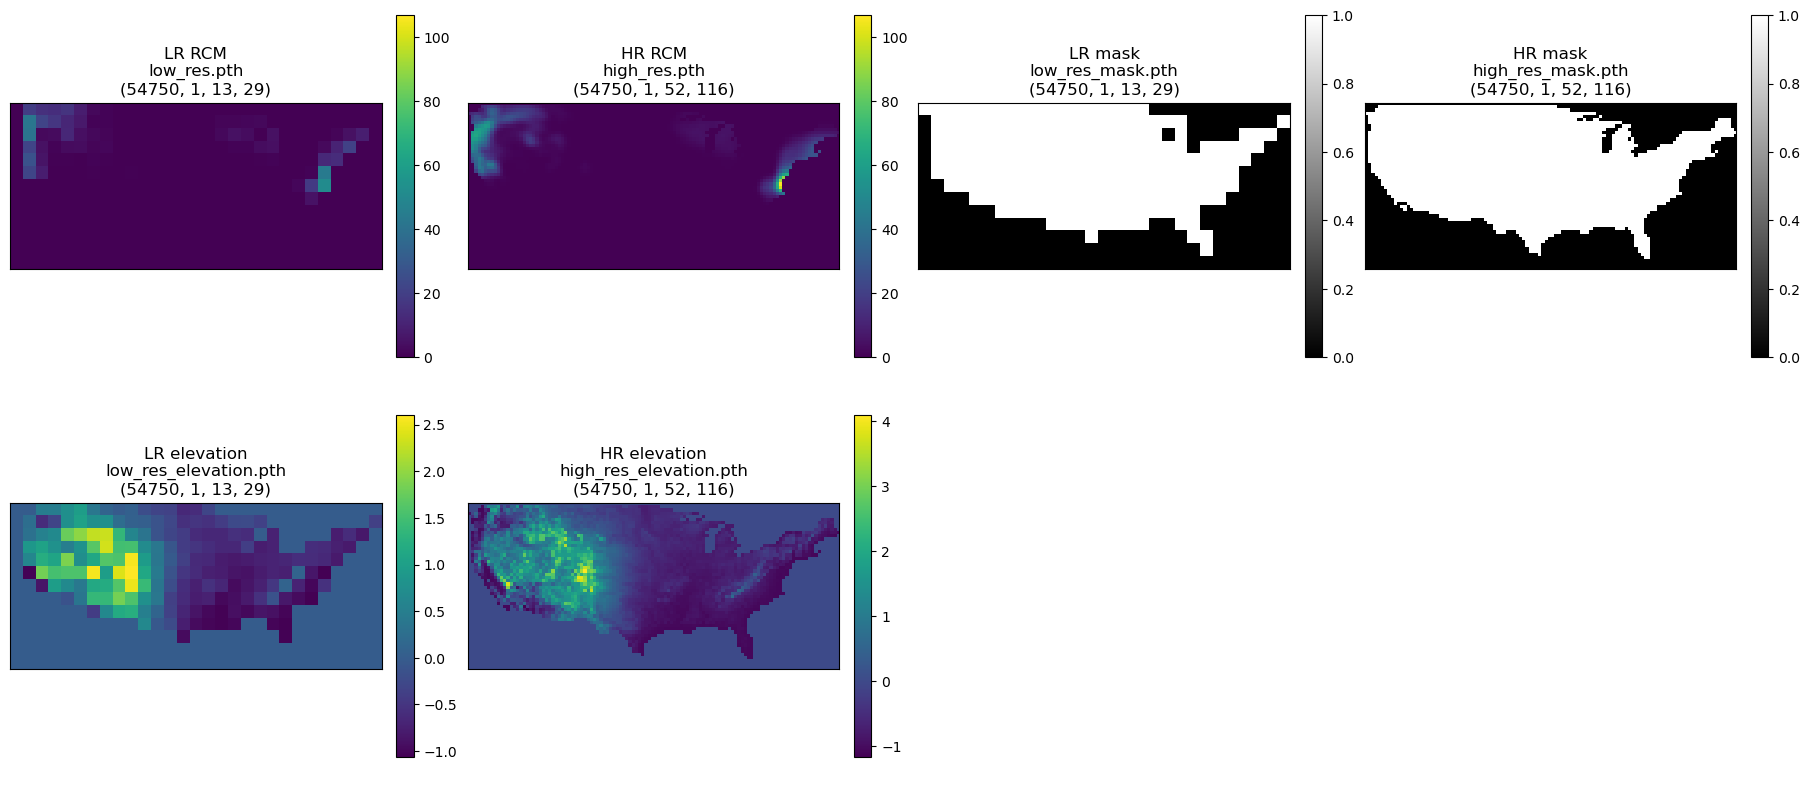

In [7]:
rcm_var = "prec"      # HR RCM target variable
gcm_var = "pr"        # GCM input variable

gcm_name = "CanESM2"
rcm_name = "RCA4"
grid = "NAM-44i"
rcm_product = "raw"
preprocess_mode = "RCM_RCM"  # "GCM_RCM" or "RCM_RCM"

# =========================================================
# Plot first sample from all saved tensors
# =========================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

if preprocess_mode not in ["GCM_RCM", "RCM_RCM"]:
    raise ValueError(f"Unknown preprocess_mode={preprocess_mode}")

preprocessed_dir = "/projects/sds-lab/Shuochen/downscaling/preprocessed"
out_tag = f"{rcm_product}.{preprocess_mode}"

out_dir = (
    f"{preprocessed_dir}/"
    f"{rcm_var}.{gcm_name}.{rcm_name}.day.{grid}.{out_tag}"
)

input_title = "LR GCM" if preprocess_mode == "GCM_RCM" else "LR RCM"

files_to_plot = [
    ("low_res.pth", input_title),
    ("high_res.pth", "HR RCM"),
    ("low_res_mask.pth", "LR mask"),
    ("high_res_mask.pth", "HR mask"),
    ("low_res_elevation.pth", "LR elevation"),
    ("high_res_elevation.pth", "HR elevation"),
]

if preprocess_mode == "GCM_RCM":
    files_to_plot.insert(1, ("high_res_gcm.pth", "HR GCM"))


def first_sample_2d(tensor):
    """Return sample 0 as a 2D numpy array from [N, C, H, W] or static variants."""
    tensor = tensor.detach().cpu().float()

    while tensor.ndim > 2:
        tensor = tensor[0]

    return tensor.numpy()


plot_items = []
for filename, title in files_to_plot:
    path = os.path.join(out_dir, filename)

    if not os.path.exists(path):
        plot_items.append((filename, title, None, None))
        continue

    tensor = torch.load(path, map_location="cpu")
    image = first_sample_2d(tensor)
    plot_items.append((filename, title, tensor, image))

data_filenames = {"low_res.pth", "high_res.pth", "high_res_gcm.pth"}
data_images = [
    image
    for filename, _, _, image in plot_items
    if filename in data_filenames and image is not None
]
if data_images:
    data_values = np.concatenate([
        image[np.isfinite(image)].ravel()
        for image in data_images
        if np.isfinite(image).any()
    ])
    data_vmin = float(data_values.min())
    data_vmax = float(data_values.max())
else:
    data_vmin = None
    data_vmax = None

ncols = 4
nrows = int(np.ceil(len(plot_items) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), constrained_layout=True)
axes_flat = np.asarray(axes).ravel()

for idx, (ax, (filename, title, tensor, image)) in enumerate(zip(axes_flat, plot_items)):
    if image is None:
        ax.set_title(f"{title}\\nmissing")
        ax.axis("off")
        continue

    is_mask = "mask" in filename
    is_data = filename in data_filenames
    cmap = "gray" if is_mask else "viridis"

    if is_mask:
        im = ax.imshow(image, origin="lower", cmap=cmap, vmin=0.0, vmax=1.0)
    elif is_data and data_vmin is not None:
        im = ax.imshow(
            image,
            origin="lower",
            cmap=cmap,
            vmin=data_vmin,
            vmax=data_vmax,
        )
    else:
        im = ax.imshow(image, origin="lower", cmap=cmap)

    ax.set_title(f"{title}\n{filename}\n{tuple(tensor.shape)}")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes_flat[len(plot_items):]:
    ax.axis("off")

plt.show()


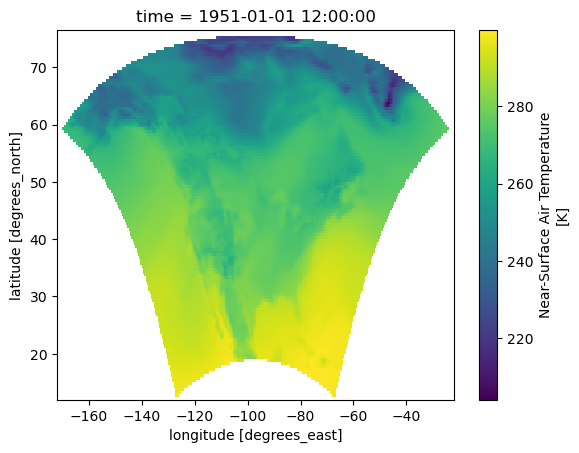

In [3]:
import xarray as xr
a=xr.open_dataset('/projects/sds-lab/Shuochen/downscaling/CORDEX/tas.hist.CanESM2.RCA4.day.NAM-44i.raw.nc')
a['tas'].isel(time=0).plot()

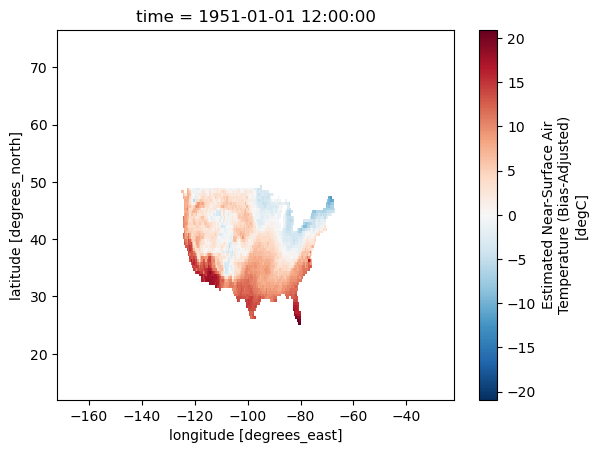

In [4]:
b=xr.open_dataset('/projects/sds-lab/Shuochen/downscaling/CORDEX/tmean.hist.CanESM2.RCA4.day.NAM-44i.mbcn-gridMET.nc')
b['tmean'].isel(time=0).plot()

In [5]:
import xarray as xr
a=xr.open_dataset('/projects/sds-lab/Shuochen/downscaling/GCM/tas_day_CanESM2_historical_r1i1p1_18500101-20051231.nc')
a['tas']= a['tas']-273.15

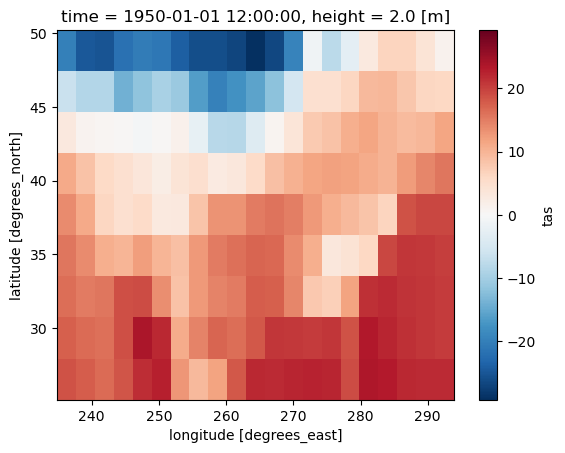

In [6]:
lat_min, lat_max = 24, 50
lon_min, lon_max = 360-125, 360-66
a['tas'].sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max)).sel(time='1950-01-01').plot()


